# Homework 2 - Data Mining
## Clustering and Classification: Iris and Wine Datasets
Algorithms: K-Means, Hierarchical, DBSCAN SVM, Decision Trees
Members: Juan Azcona, Daniel Cardenas

## 1. Imports and Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    homogeneity_score, completeness_score, v_measure_score,
    adjusted_rand_score, normalized_mutual_info_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
from mpl_toolkits.mplot3d import Axes3D

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load Datasets and EDA

In [2]:
# load Iris and Wine from sklearn
iris = load_iris()
wine = load_wine()

datasets = {
    "Iris": {
        "X": iris.data,
        "y": iris.target,
        "feature_names": iris.feature_names,
        "target_names": iris.target_names,
    },
    "Wine": {
        "X": wine.data,
        "y": wine.target,
        "feature_names": wine.feature_names,
        "target_names": wine.target_names,
    },
}

for name, ds in datasets.items():
    df = pd.DataFrame(ds["X"], columns=ds["feature_names"])
    df["target"] = ds["y"]
    print(f"\n--- {name} ---")
    print(f"Shape: {ds['X'].shape}")
    print(f"Classes: {ds['target_names']}")
    print(f"Class distribution:\n{pd.Series(ds['y']).value_counts().sort_index()}")
    print(df.describe().round(3))


--- Iris ---
Shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Class distribution:
0    50
1    50
2    50
Name: count, dtype: int64
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count            150.000           150.000            150.000   
mean               5.843             3.057              3.758   
std                0.828             0.436              1.765   
min                4.300             2.000              1.000   
25%                5.100             2.800              1.600   
50%                5.800             3.000              4.350   
75%                6.400             3.300              5.100   
max                7.900             4.400              6.900   

       petal width (cm)   target  
count           150.000  150.000  
mean              1.199    1.000  
std               0.762    0.819  
min               0.100    0.000  
25%               0.300    0.000  
50%               1.300    1.000  
75%               1.800 

## 3. Preprocessing - StandardScaler

In [3]:
scaler = StandardScaler()
for ds in datasets.values():
    ds["X_scaled"] = scaler.fit_transform(ds["X"])

print("Scaling done. Mean ~ 0, Std ~ 1 for all features.")

Scaling done. Mean ~ 0, Std ~ 1 for all features.


## 4. Shared Metric Functions

In [4]:
def cluster_metrics(X, labels, y_true):
    # returns NaN row if fewer than 2 valid clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    nan_row = {k: np.nan for k in [
        "n_clusters", "silhouette", "davies_bouldin",
        "calinski_harabasz", "homogeneity", "completeness",
        "v_measure", "ari", "nmi"
    ]}
    if n_clusters < 2:
        return nan_row

    valid = labels != -1
    Xv, lv, yv = X[valid], labels[valid], y_true[valid]

    return {
        "n_clusters": n_clusters,
        "silhouette": round(silhouette_score(Xv, lv), 4),
        "davies_bouldin": round(davies_bouldin_score(Xv, lv), 4),
        "calinski_harabasz": round(calinski_harabasz_score(Xv, lv), 4),
        "homogeneity": round(homogeneity_score(yv, lv), 4),
        "completeness": round(completeness_score(yv, lv), 4),
        "v_measure": round(v_measure_score(yv, lv), 4),
        "ari": round(adjusted_rand_score(yv, lv), 4),
        "nmi": round(normalized_mutual_info_score(yv, lv), 4),
    }


def clf_metrics(y_true, y_pred):
    return {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred,
                           average="weighted", zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred,
                        average="weighted", zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred,
                   average="weighted", zero_division=0), 4),
    }


def plot_cm(y_true, y_pred, title, ax, target_names):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

print("Helper functions defined.")

Helper functions defined.


---
# CLUSTERING
## 5. K-Means (k = 2 to 10)

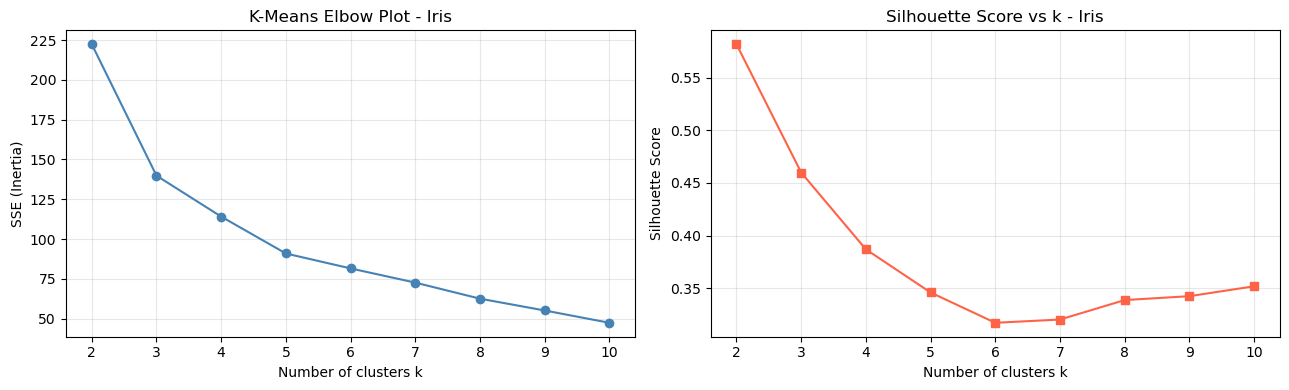


K-Means - Iris
 k  n_clusters  silhouette  davies_bouldin  calinski_harabasz  homogeneity  completeness  v_measure    ari    nmi
 2           2      0.5818          0.5933           251.3493       0.5794        1.0000     0.7337 0.5681 0.7337
 3           3      0.4599          0.8336           241.9044       0.6591        0.6598     0.6595 0.6201 0.6595
 4           4      0.3869          0.8698           207.2659       0.6591        0.5461     0.5973 0.4728 0.5973
 5           5      0.3459          0.9483           202.9515       0.7465        0.5234     0.6154 0.4348 0.6154
 6           6      0.3171          1.0537           183.1091       0.7855        0.4831     0.5983 0.4502 0.5983
 7           7      0.3202          0.9905           173.0519       0.8144        0.4749     0.6000 0.4340 0.6000
 8           8      0.3387          0.9150           174.3307       0.7027        0.4012     0.5108 0.2937 0.5108
 9           9      0.3424          0.9032           174.2309       0.74

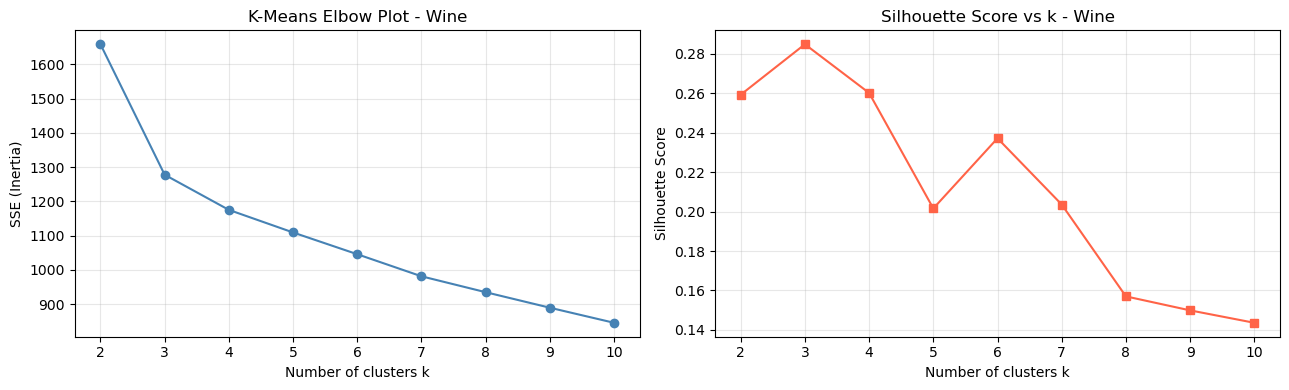


K-Means - Wine
 k  n_clusters  silhouette  davies_bouldin  calinski_harabasz  homogeneity  completeness  v_measure    ari    nmi
 2           2      0.2593          1.5260            69.5233       0.3917        0.6139     0.4782 0.3743 0.4782
 3           3      0.2849          1.3892            70.9400       0.8788        0.8730     0.8759 0.8975 0.8759
 4           4      0.2602          1.7969            56.1814       0.9146        0.7297     0.8117 0.7646 0.8117
 5           5      0.2016          1.8083            46.9522       0.8190        0.5710     0.6729 0.5991 0.6729
 6           6      0.2372          1.5544            41.7008       0.8749        0.5865     0.7023 0.6391 0.7023
 7           7      0.2036          1.6606            38.6855       0.8872        0.5438     0.6743 0.5655 0.6743
 8           8      0.1570          1.7409            35.8053       0.8309        0.4588     0.5912 0.4154 0.5912
 9           9      0.1499          1.7083            33.8066       0.85

In [5]:
kmeans_results = {}

for name, ds in datasets.items():
    X, y = ds["X_scaled"], ds["y"]
    k_range = range(2, 11)
    sse, rows = [], []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X)
        sse.append(km.inertia_)
        row = {"k": k}
        row.update(cluster_metrics(X, labels, y))
        rows.append(row)

    df = pd.DataFrame(rows)
    kmeans_results[name] = {"df": df, "sse": sse, "k_range": list(k_range)}
    df.to_csv(f"{RESULTS_DIR}/{name}_kmeans.csv", index=False)

    # elbow + silhouette
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(list(k_range), sse, marker="o", color="steelblue")
    axes[0].set_title(f"K-Means Elbow Plot - {name}")
    axes[0].set_xlabel("Number of clusters k")
    axes[0].set_ylabel("SSE (Inertia)")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df["k"], df["silhouette"], marker="s", color="tomato")
    axes[1].set_title(f"Silhouette Score vs k - {name}")
    axes[1].set_xlabel("Number of clusters k")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_kmeans_elbow.png", dpi=150)
    plt.show()

    print(f"\nK-Means - {name}")
    print(df.to_string(index=False))

### 5.1 Silhouette Plots for k = 3 and k = 4

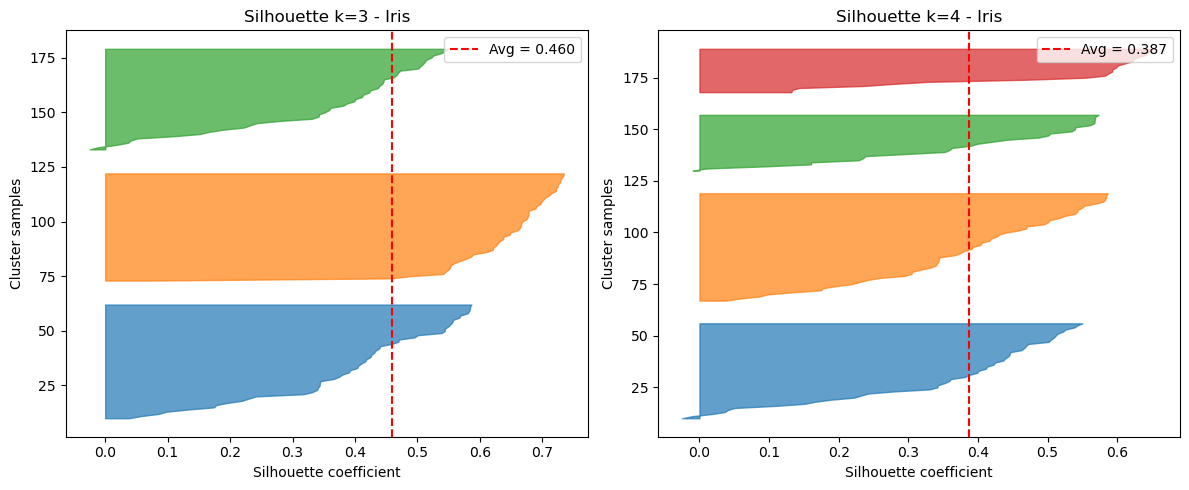

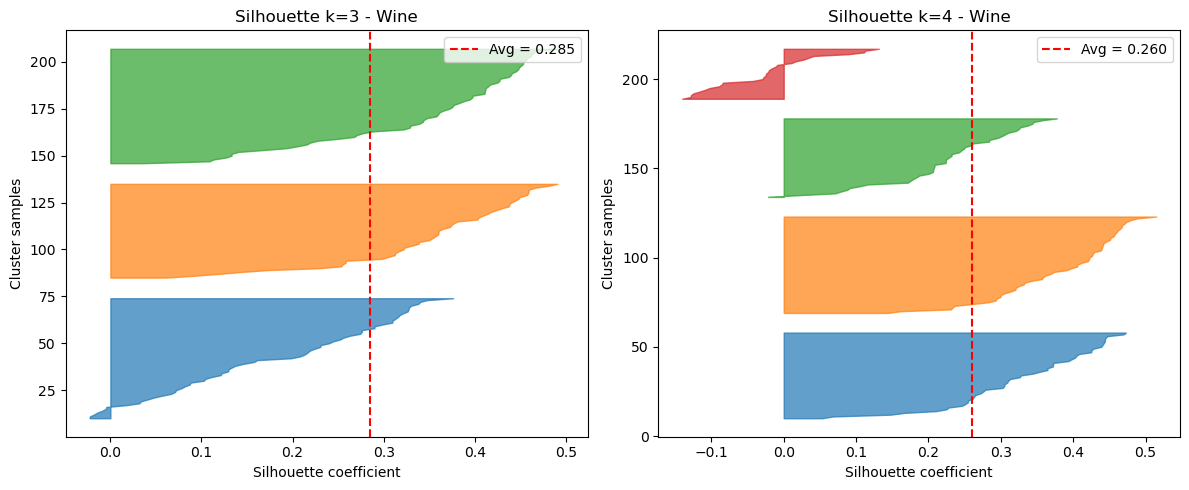

In [6]:
for name, ds in datasets.items():
    X = ds["X_scaled"]
    cmap = plt.cm.get_cmap("tab10")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, k in zip(axes, [3, 4]):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X)
        sil_vals = silhouette_samples(X, labels)
        avg = silhouette_score(X, labels)

        y_lower = 10
        for i in range(k):
            cv = np.sort(sil_vals[labels == i])
            y_upper = y_lower + cv.shape[0]
            ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cv,
                             alpha=0.7, color=cmap(i))
            y_lower = y_upper + 10

        ax.axvline(avg, color="red", linestyle="--",
                   label=f"Avg = {avg:.3f}")
        ax.set_title(f"Silhouette k={k} - {name}")
        ax.set_xlabel("Silhouette coefficient")
        ax.set_ylabel("Cluster samples")
        ax.legend()

    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_silhouette_k34.png", dpi=150)
    plt.show()

## 6. Hierarchical Clustering (ward, complete, average, single)

In [7]:
hierarchical_results = {}
linkages = ["ward", "complete", "average", "single"]

for name, ds in datasets.items():
    X, y = ds["X_scaled"], ds["y"]
    rows = []

    for link in linkages:
        for k in range(2, 11):
            hc = AgglomerativeClustering(n_clusters=k, linkage=link)
            labels = hc.fit_predict(X)
            row = {"linkage": link, "k": k}
            row.update(cluster_metrics(X, labels, y))
            rows.append(row)

    df = pd.DataFrame(rows)
    hierarchical_results[name] = df
    df.to_csv(f"{RESULTS_DIR}/{name}_hierarchical.csv", index=False)

    print(f"\nHierarchical (k=3) - {name}")
    print(df[df["k"] == 3].to_string(index=False))


Hierarchical (k=3) - Iris
 linkage  k  n_clusters  silhouette  davies_bouldin  calinski_harabasz  homogeneity  completeness  v_measure    ari    nmi
    ward  3           3      0.4467          0.8035           222.7192       0.6579        0.6940     0.6755 0.6153 0.6755
complete  3           3      0.4496          0.7584           213.0817       0.6240        0.6849     0.6530 0.5726 0.6530
 average  3           3      0.4803          0.5753           149.0258       0.5923        0.8958     0.7131 0.5621 0.7131
  single  3           3      0.5046          0.4929           131.5359       0.5794        0.9512     0.7201 0.5584 0.7201

Hierarchical (k=3) - Wine
 linkage  k  n_clusters  silhouette  davies_bouldin  calinski_harabasz  homogeneity  completeness  v_measure     ari    nmi
    ward  3           3      0.2774          1.4186            67.6475       0.7904        0.7825     0.7865  0.7899 0.7865
complete  3           3      0.2038          1.8961            48.9898       0.6157

### 6.1 Dendrograms

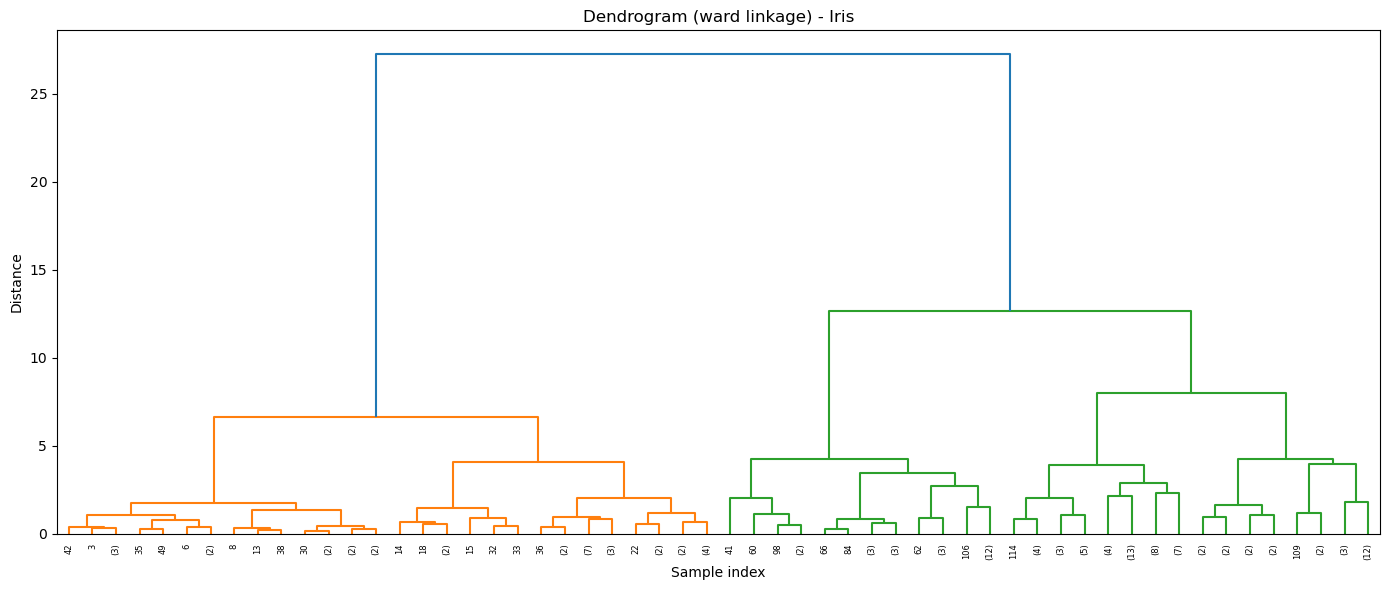

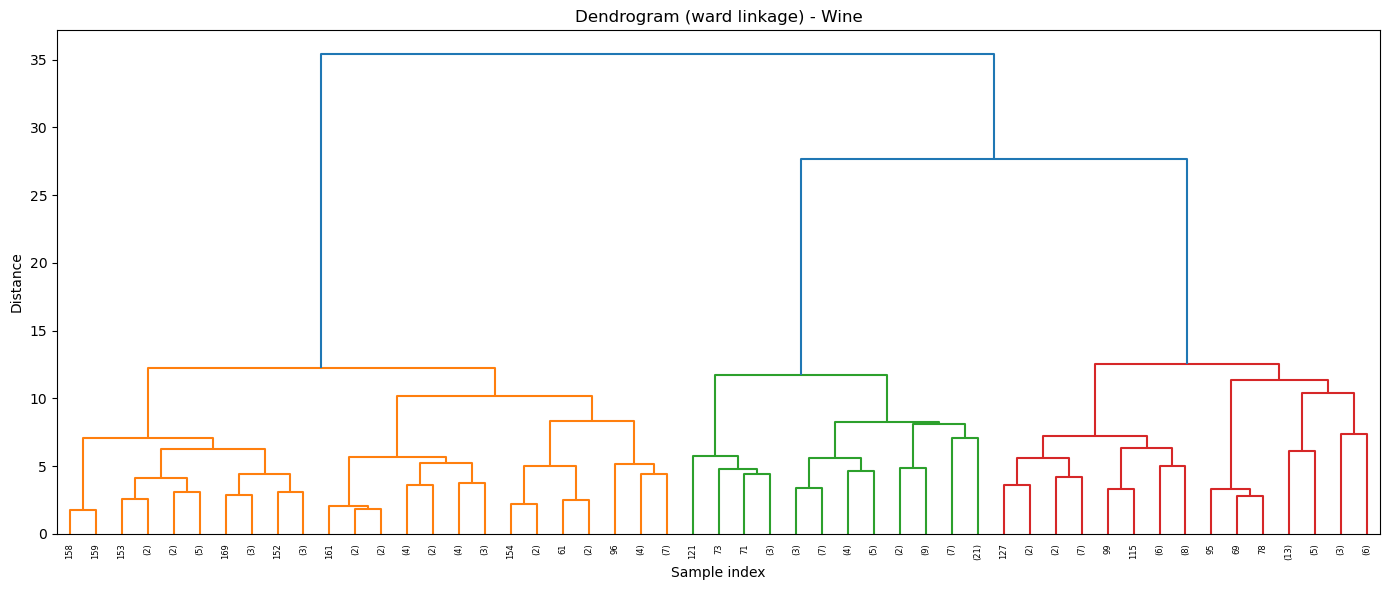

In [8]:
for name, ds in datasets.items():
    X = ds["X_scaled"]
    Z = scipy_linkage(X, method="ward")

    fig, ax = plt.subplots(figsize=(14, 6))
    dendrogram(Z, ax=ax, truncate_mode="level", p=5,
               color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f"Dendrogram (ward linkage) - {name}")
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Distance")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_dendrogram.png", dpi=150)
    plt.show()

### 6.2 Linkage Comparison (k = 3)

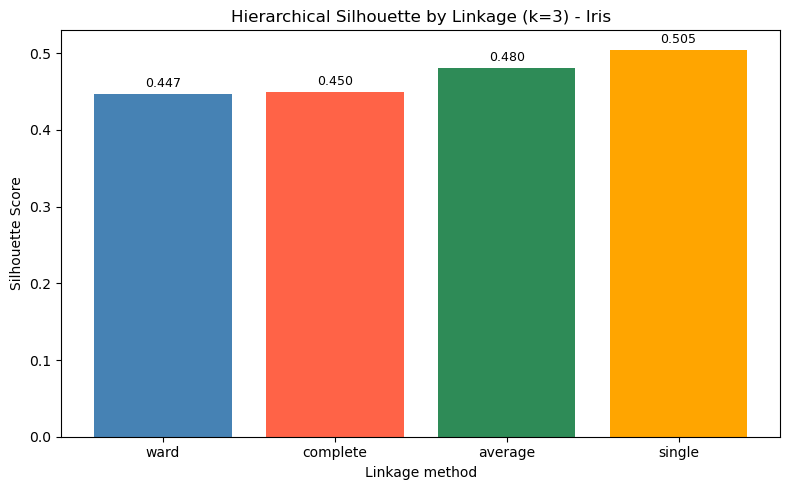

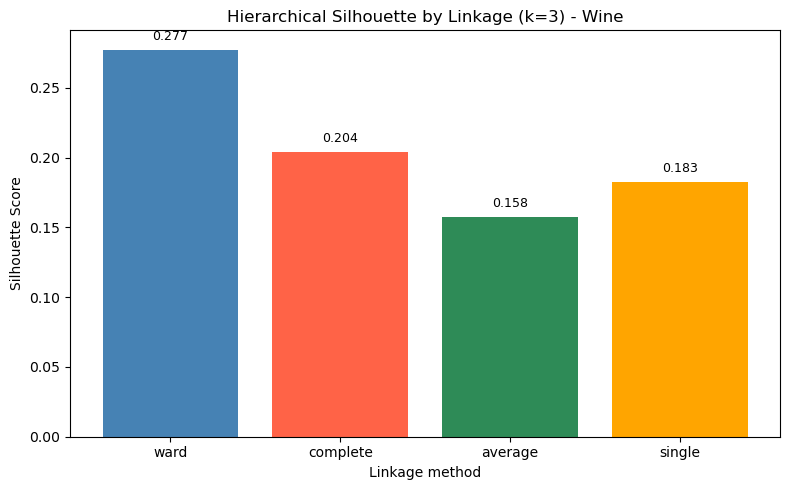

In [9]:
for name, df in hierarchical_results.items():
    subset = df[df["k"] == 3].dropna(subset=["silhouette"])

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["steelblue", "tomato", "seagreen", "orange"]
    bars = ax.bar(subset["linkage"], subset["silhouette"], color=colors)
    ax.set_title(f"Hierarchical Silhouette by Linkage (k=3) - {name}")
    ax.set_xlabel("Linkage method")
    ax.set_ylabel("Silhouette Score")
    for bar, val in zip(bars, subset["silhouette"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_hierarchical_linkage.png", dpi=150)
    plt.show()

## 7. DBSCAN - Grid Search (eps, min_samples)

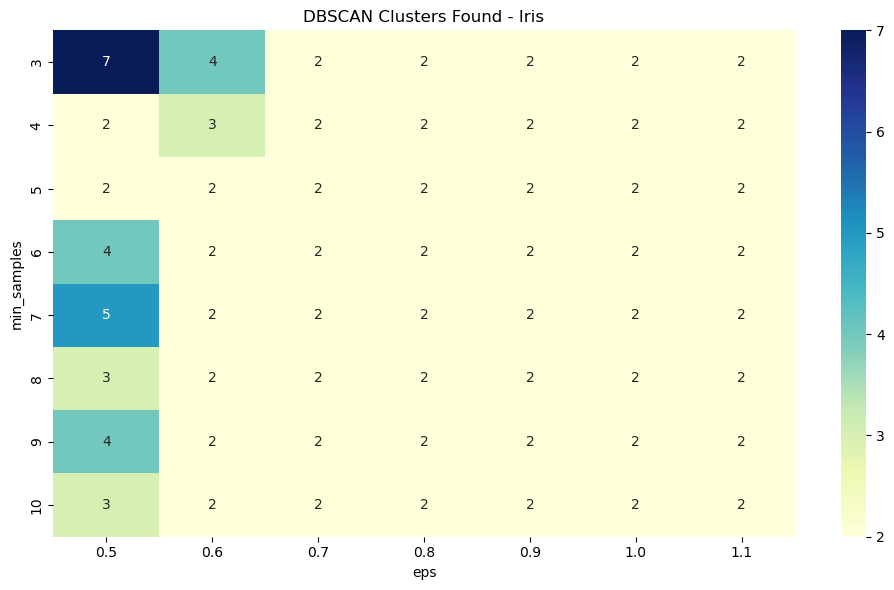


DBSCAN Best Config - Iris
eps             0.5000
min_samples    10.0000
n_clusters      3.0000
n_noise        89.0000
silhouette      0.7101
ari             1.0000
nmi             1.0000


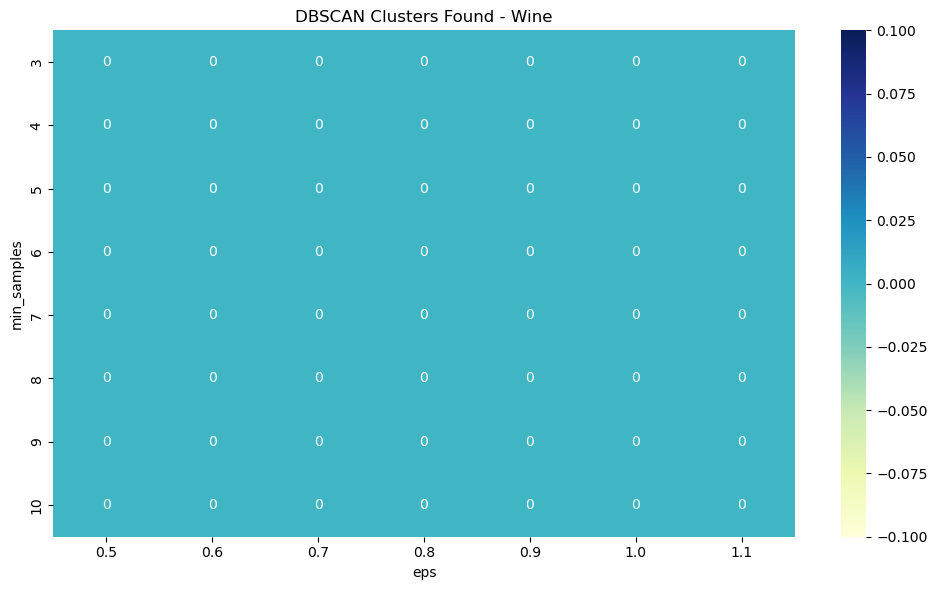


DBSCAN: no valid clustering found for Wine


In [10]:
dbscan_results = {}
eps_values = np.arange(0.5, 1.15, 0.1).round(2)
min_samples_values = range(3, 11)

for name, ds in datasets.items():
    X, y = ds["X_scaled"], ds["y"]
    rows = []

    for eps in eps_values:
        for ms in min_samples_values:
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(X)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = int((labels == -1).sum())

            row = {"eps": eps, "min_samples": ms,
                   "n_clusters": n_clusters, "n_noise": n_noise}
            if n_clusters >= 2:
                metrics = cluster_metrics(X, labels, y)
                row["silhouette"] = metrics["silhouette"]
                row["ari"] = metrics["ari"]
                row["nmi"] = metrics["nmi"]
            else:
                row["silhouette"] = np.nan
                row["ari"] = np.nan
                row["nmi"] = np.nan
            rows.append(row)

    df = pd.DataFrame(rows)
    dbscan_results[name] = df
    df.to_csv(f"{RESULTS_DIR}/{name}_dbscan.csv", index=False)

    # heatmap of cluster counts
    pivot = df.pivot_table(index="min_samples", columns="eps",
                           values="n_clusters", aggfunc="first")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"DBSCAN Clusters Found - {name}")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_dbscan_heatmap.png", dpi=150)
    plt.show()

    valid = df.dropna(subset=["silhouette"])
    if not valid.empty:
        best = valid.loc[valid["silhouette"].idxmax()]
        print(f"\nDBSCAN Best Config - {name}")
        print(best.to_string())
    else:
        print(f"\nDBSCAN: no valid clustering found for {name}")

## 8. Cluster Scatter Plots (PCA 2D)

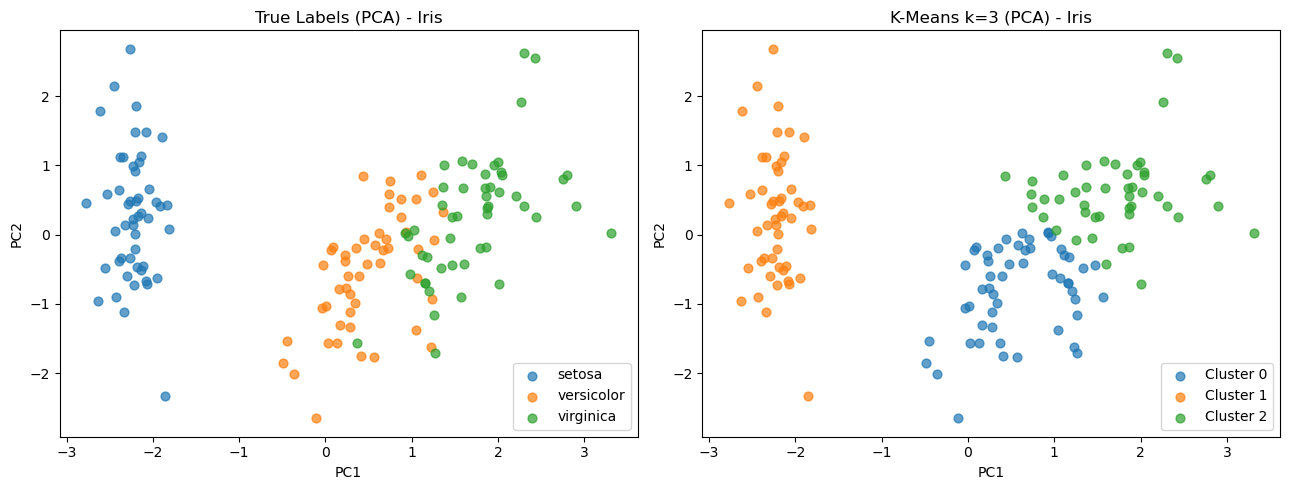

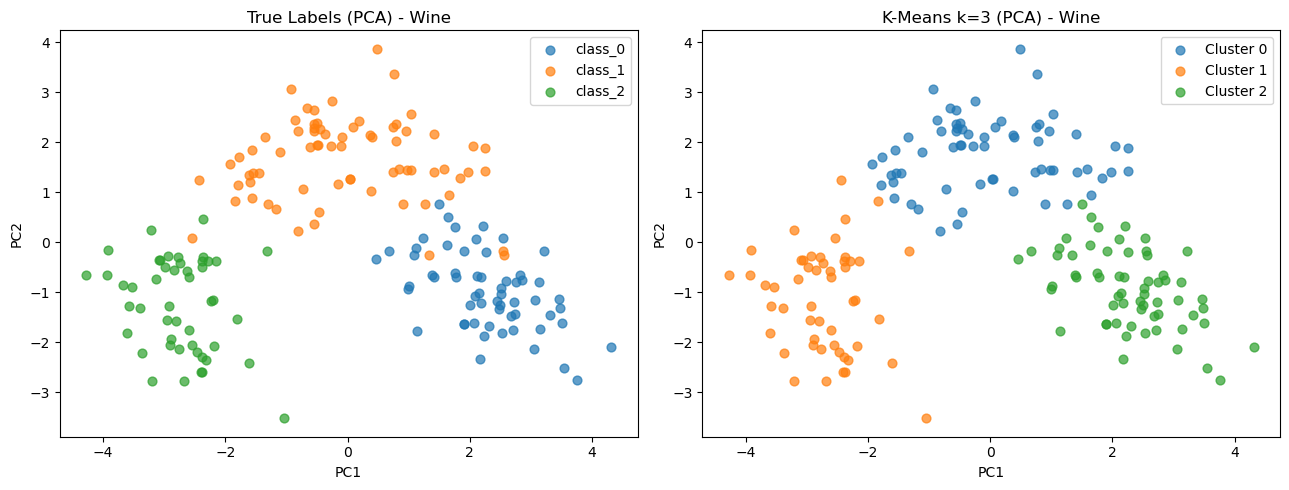

In [11]:
for name, ds in datasets.items():
    X, y = ds["X_scaled"], ds["y"]
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X2 = pca.fit_transform(X)

    km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(X)

    cmap = plt.cm.get_cmap("tab10")
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for cls in np.unique(y):
        mask = y == cls
        axes[0].scatter(X2[mask, 0], X2[mask, 1], color=cmap(cls),
                        label=ds["target_names"][cls], alpha=0.7, s=40)
    axes[0].set_title(f"True Labels (PCA) - {name}")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend()

    for cls in np.unique(km_labels):
        mask = km_labels == cls
        axes[1].scatter(X2[mask, 0], X2[mask, 1], color=cmap(cls),
                        label=f"Cluster {cls}", alpha=0.7, s=40)
    axes[1].set_title(f"K-Means k=3 (PCA) - {name}")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_scatter.png", dpi=150)
    plt.show()

---
# CLASSIFICATION
## 9. SVM - Kernels: linear, rbf, poly

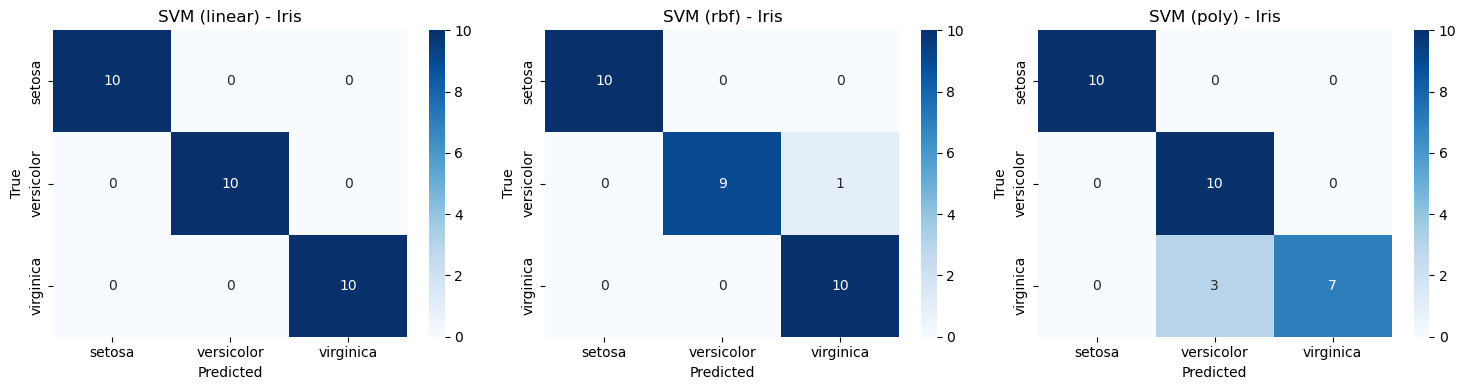

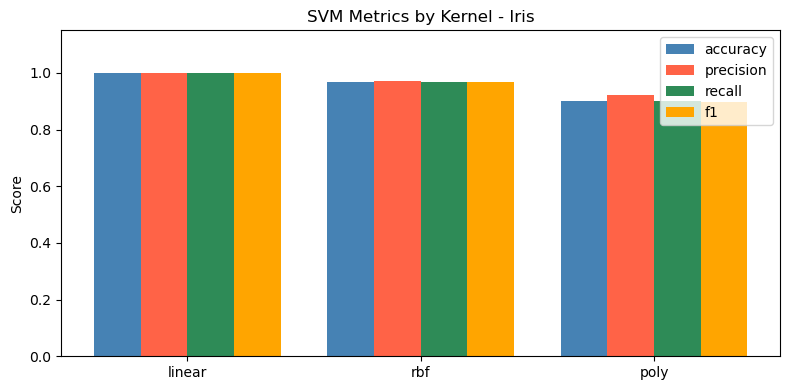


SVM Results - Iris
kernel  accuracy  precision  recall     f1
linear    1.0000     1.0000  1.0000 1.0000
   rbf    0.9667     0.9697  0.9667 0.9666
  poly    0.9000     0.9231  0.9000 0.8977


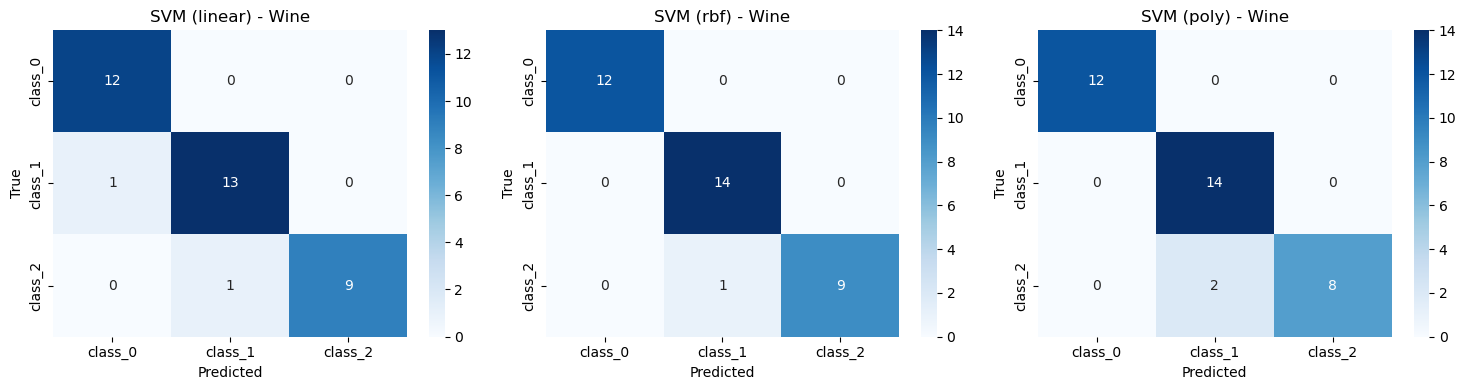

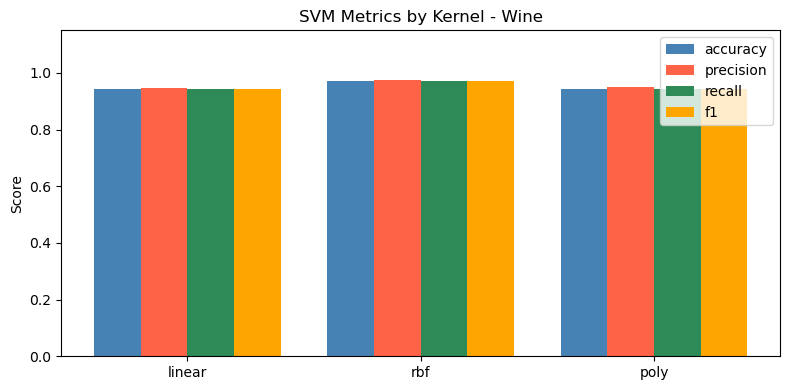


SVM Results - Wine
kernel  accuracy  precision  recall     f1
linear    0.9444     0.9466  0.9444 0.9443
   rbf    0.9722     0.9741  0.9722 0.9720
  poly    0.9444     0.9514  0.9444 0.9432


In [12]:
svm_results = {}
kernels = ["linear", "rbf", "poly"]

for name, ds in datasets.items():
    X, y = ds["X_scaled"], ds["y"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    rows, cms = [], {}
    for kernel in kernels:
        clf = SVC(kernel=kernel, random_state=RANDOM_STATE, gamma="scale")
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        row = {"kernel": kernel}
        row.update(clf_metrics(y_test, y_pred))
        rows.append(row)
        cms[kernel] = y_pred

    df = pd.DataFrame(rows)
    svm_results[name] = {"df": df, "cms": cms,
                         "y_test": y_test,
                         "target_names": ds["target_names"]}
    df.to_csv(f"{RESULTS_DIR}/{name}_svm.csv", index=False)

    # confusion matrices
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, kernel in zip(axes, kernels):
        plot_cm(y_test, cms[kernel],
                f"SVM ({kernel}) - {name}",
                ax, ds["target_names"])
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_svm_cm.png", dpi=150)
    plt.show()

    # grouped bar comparison
    metric_cols = ["accuracy", "precision", "recall", "f1"]
    x = np.arange(len(kernels))
    width = 0.2
    colors = ["steelblue", "tomato", "seagreen", "orange"]

    fig, ax = plt.subplots(figsize=(8, 4))
    for i, (metric, color) in enumerate(zip(metric_cols, colors)):
        ax.bar(x + i * width, df[metric], width, label=metric, color=color)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(kernels)
    ax.set_title(f"SVM Metrics by Kernel - {name}")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.15)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_svm_metrics.png", dpi=150)
    plt.show()

    print(f"\nSVM Results - {name}")
    print(df.to_string(index=False))

## 10. Decision Trees - max_depth: 3, 5, 7, 10, 15

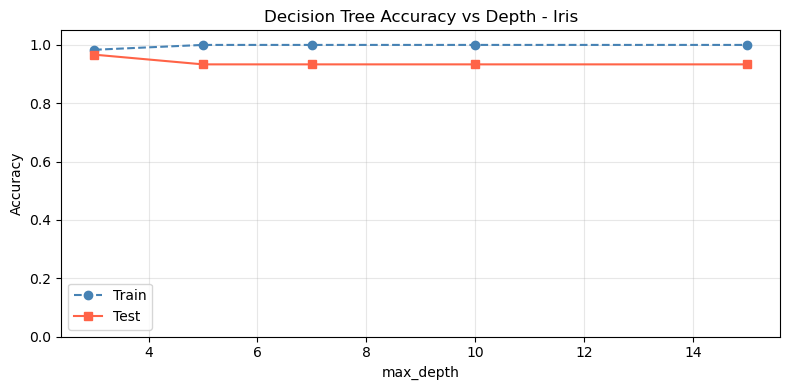

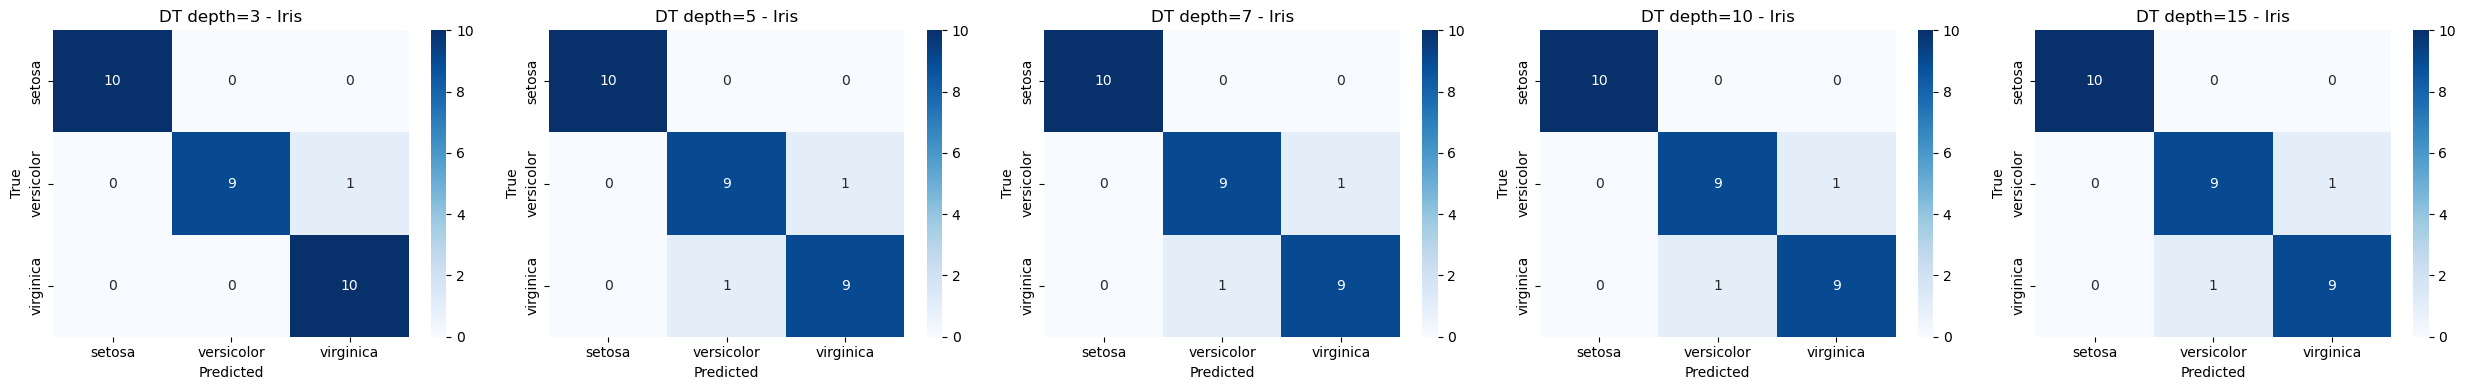


Decision Tree Results - Iris
 max_depth  train_accuracy  accuracy  precision  recall     f1
         3          0.9833    0.9667     0.9697  0.9667 0.9666
         5          1.0000    0.9333     0.9333  0.9333 0.9333
         7          1.0000    0.9333     0.9333  0.9333 0.9333
        10          1.0000    0.9333     0.9333  0.9333 0.9333
        15          1.0000    0.9333     0.9333  0.9333 0.9333


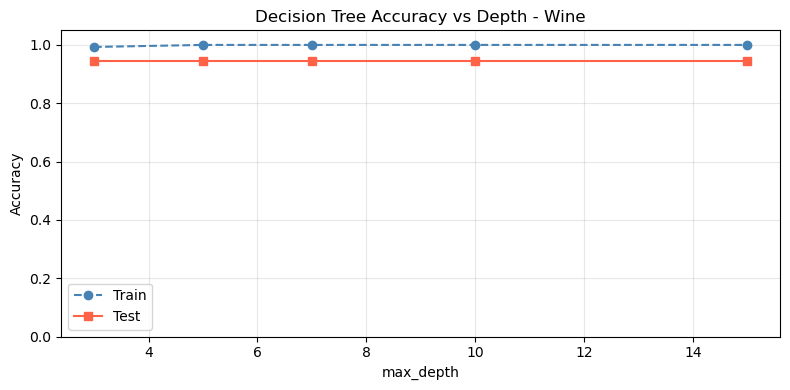

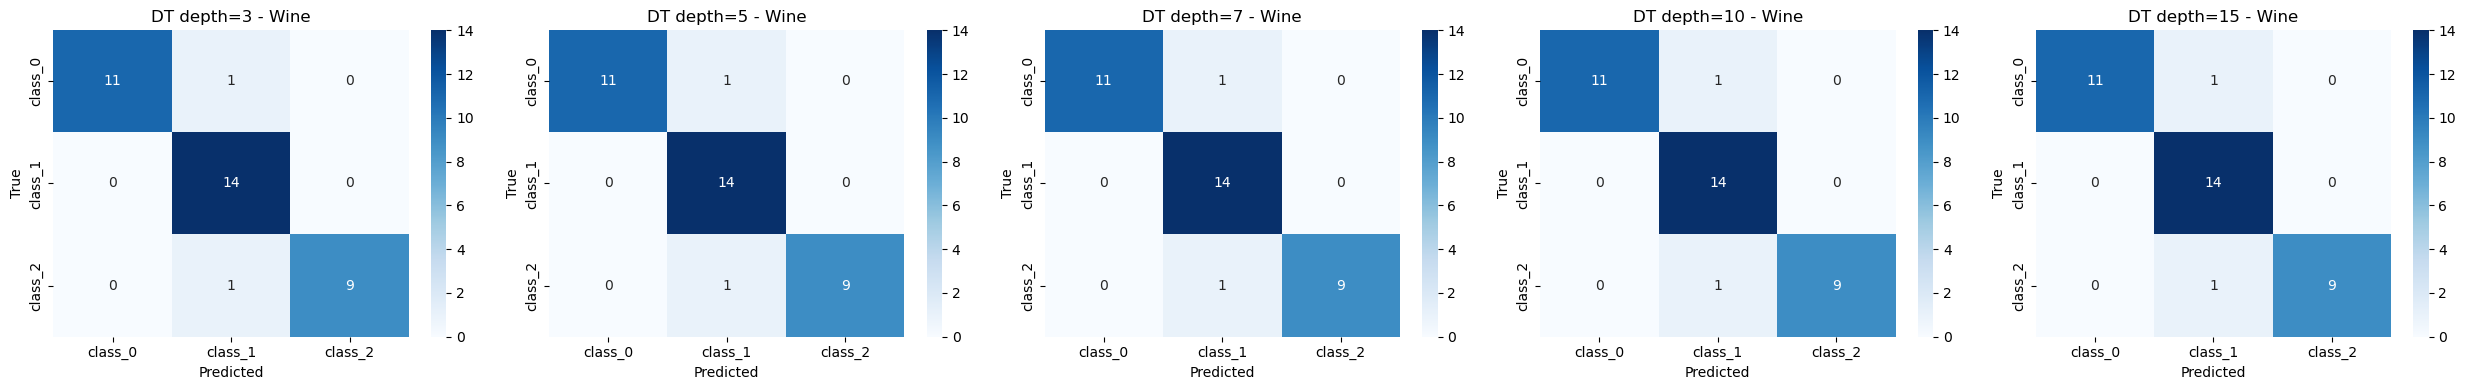


Decision Tree Results - Wine
 max_depth  train_accuracy  accuracy  precision  recall    f1
         3           0.993    0.9444     0.9514  0.9444 0.945
         5           1.000    0.9444     0.9514  0.9444 0.945
         7           1.000    0.9444     0.9514  0.9444 0.945
        10           1.000    0.9444     0.9514  0.9444 0.945
        15           1.000    0.9444     0.9514  0.9444 0.945


In [13]:
dt_results = {}
depths = [3, 5, 7, 10, 15]

for name, ds in datasets.items():
    X, y = ds["X_scaled"], ds["y"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    rows = []
    for depth in depths:
        dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
        dt.fit(X_train, y_train)
        row = {"max_depth": depth,
               "train_accuracy": round(
                   accuracy_score(y_train, dt.predict(X_train)), 4)}
        row.update(clf_metrics(y_test, dt.predict(X_test)))
        rows.append(row)

    df = pd.DataFrame(rows)
    dt_results[name] = df
    df.to_csv(f"{RESULTS_DIR}/{name}_dt.csv", index=False)

    # accuracy vs depth
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(df["max_depth"], df["train_accuracy"], marker="o",
            linestyle="--", color="steelblue", label="Train")
    ax.plot(df["max_depth"], df["accuracy"], marker="s",
            color="tomato", label="Test")
    ax.set_title(f"Decision Tree Accuracy vs Depth - {name}")
    ax.set_xlabel("max_depth")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_dt_accuracy.png", dpi=150)
    plt.show()

    # confusion matrices for all depths
    fig, axes = plt.subplots(1, len(depths), figsize=(5 * len(depths), 4))
    for ax, depth in zip(axes, depths):
        dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
        dt.fit(X_train, y_train)
        plot_cm(y_test, dt.predict(X_test),
                f"DT depth={depth} - {name}",
                ax, ds["target_names"])
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_dt_cm.png", dpi=150)
    plt.show()

    print(f"\nDecision Tree Results - {name}")
    print(df.to_string(index=False))

### 10.1 Tree Visualization (depth = 5)

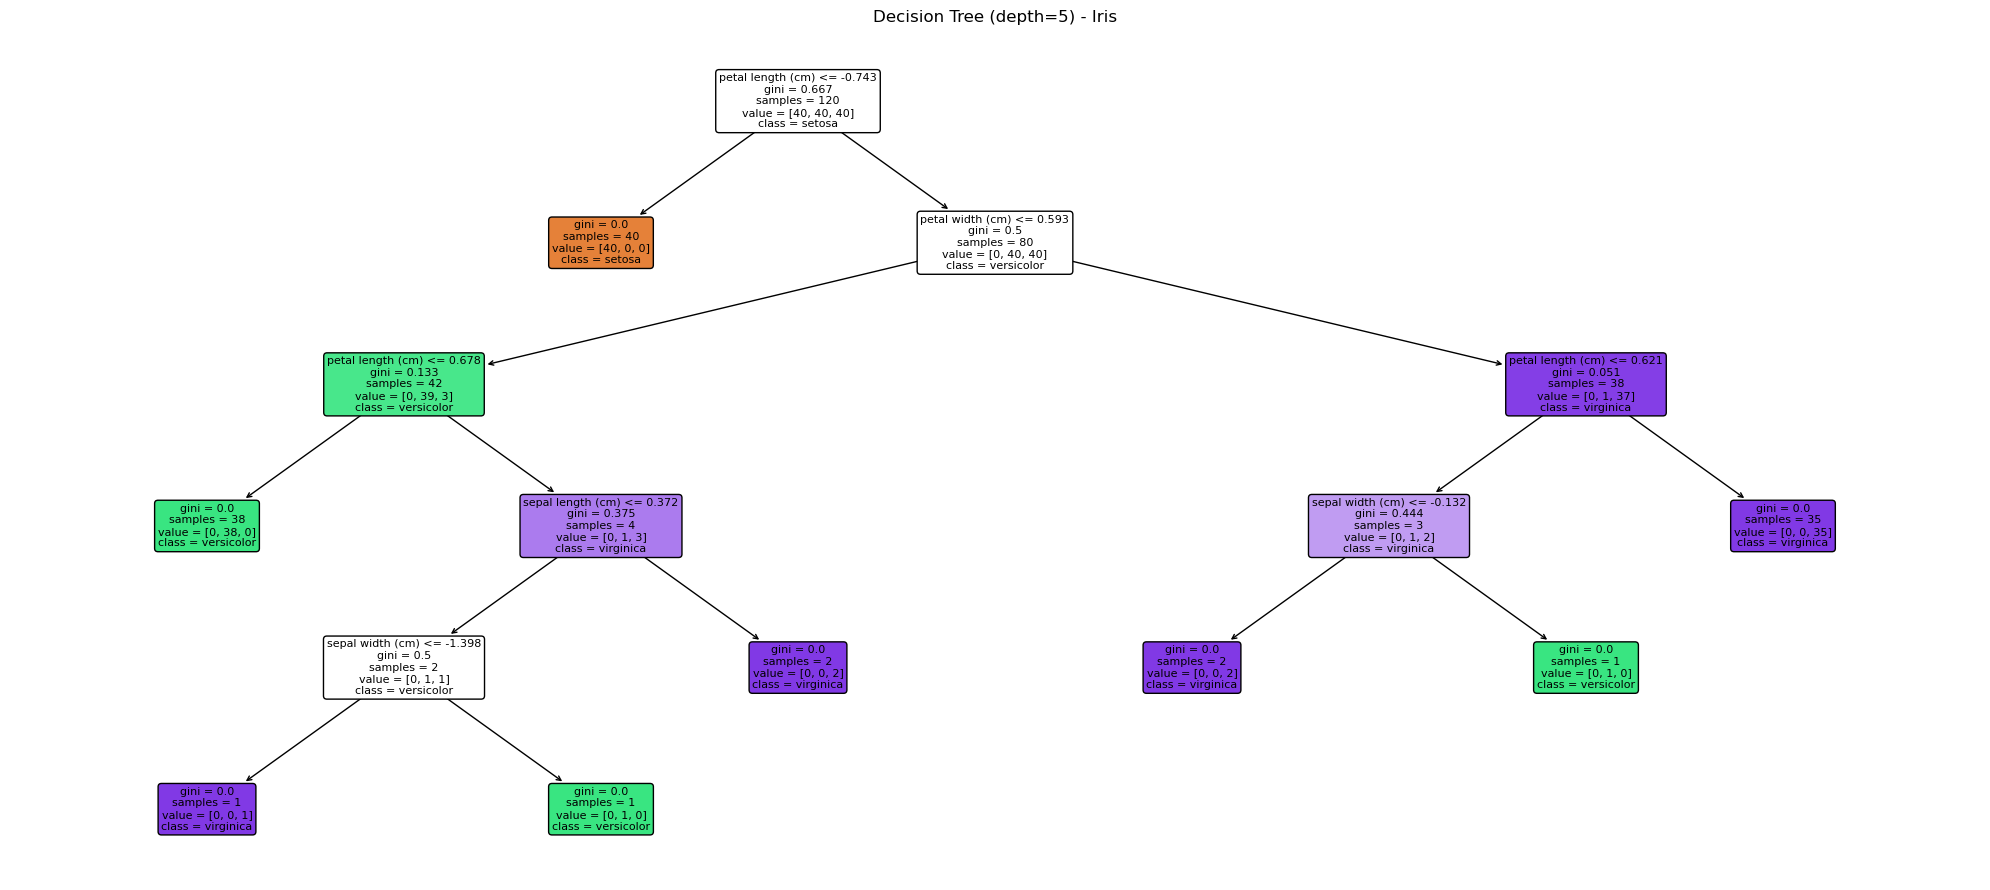

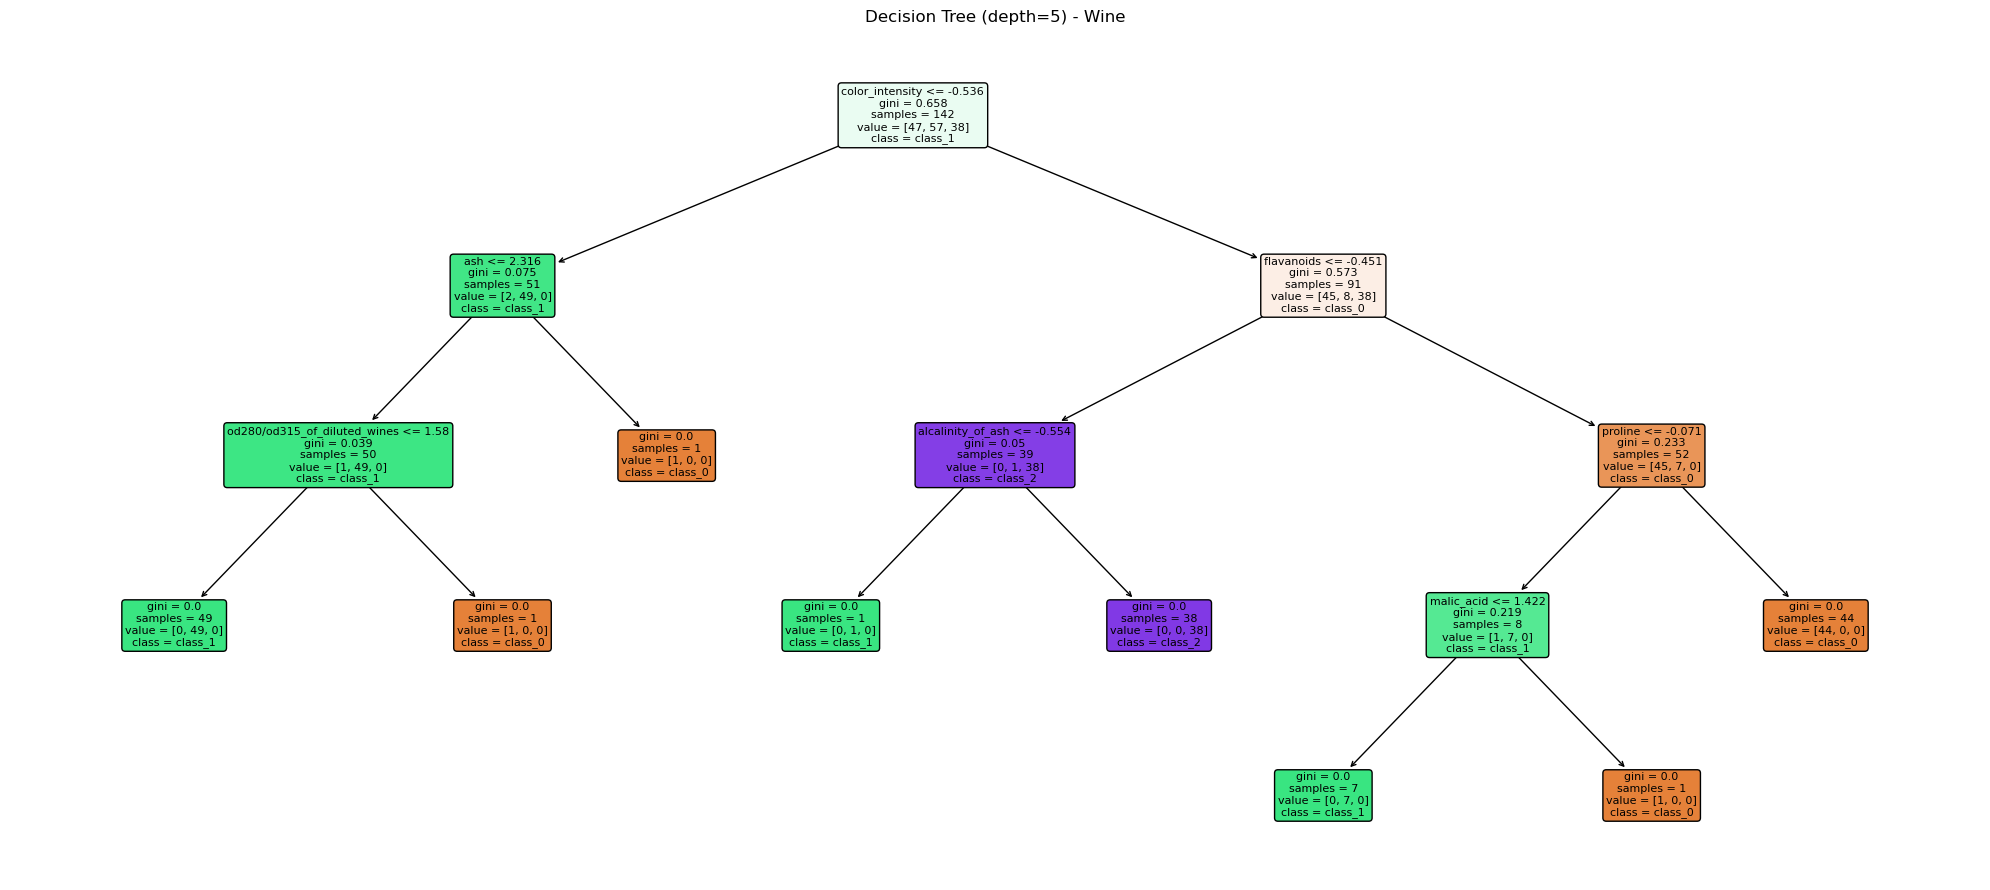

In [14]:
for name, ds in datasets.items():
    X, y = ds["X_scaled"], ds["y"]
    X_train, _, y_train, _ = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)

    fig, ax = plt.subplots(figsize=(20, 9))
    plot_tree(dt,
              feature_names=ds["feature_names"],
              class_names=list(ds["target_names"]),
              filled=True, rounded=True, fontsize=8, ax=ax)
    ax.set_title(f"Decision Tree (depth=5) - {name}")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_dt_tree.png", dpi=150)
    plt.show()

---
# SOM NEURAL NETWORK
## SOM - Implementation from Scratch (Iris dataset)
Testing topologies **5×5** and **10×10** with learning rates **0.1, 0.3, 0.5, 0.8**.

In [15]:
class SOM:
    """
    Self-Organizing Map implemented from scratch.
    m x n grid, trains with competitive learning + neighbourhood function.
    """
    def __init__(self, m, n, input_len, learning_rate=0.5, sigma=None,
                 n_iterations=100, random_state=42):
        self.m, self.n = m, n
        self.input_len = input_len
        self.lr0 = learning_rate
        self.sigma0 = sigma if sigma else max(m, n) / 2.0
        self.n_iterations = n_iterations
        rng = np.random.RandomState(random_state)
        self.weights = rng.rand(m, n, input_len)

    def _decay(self, val, t):
        return val * np.exp(-t / self.n_iterations)

    def _find_bmu(self, x):
        d2 = np.sum((self.weights - x) ** 2, axis=2)
        return np.unravel_index(np.argmin(d2), d2.shape)

    def _neighbourhood(self, bmu, sigma):
        ii, jj = np.meshgrid(np.arange(self.m), np.arange(self.n), indexing='ij')
        d2 = (ii - bmu[0]) ** 2 + (jj - bmu[1]) ** 2
        return np.exp(-d2 / (2 * max(sigma, 0.5) ** 2))

    def train(self, X):
        errors = []
        rng = np.random.RandomState(0)
        for t in range(self.n_iterations):
            lr = self._decay(self.lr0, t)
            sigma = self._decay(self.sigma0, t)
            epoch_err = 0.0
            for x in X[rng.permutation(len(X))]:
                bmu = self._find_bmu(x)
                h = self._neighbourhood(bmu, sigma)
                self.weights += lr * h[:, :, np.newaxis] * (x - self.weights)
                epoch_err += np.min(np.sum((self.weights - x) ** 2, axis=2))
            errors.append(epoch_err / len(X))
        return errors

    def predict(self, X):
        return np.array([self._find_bmu(x)[0] * self.n + self._find_bmu(x)[1]
                         for x in X])

    def activation_map(self, X):
        freq = np.zeros((self.m, self.n))
        for x in X:
            freq[self._find_bmu(x)] += 1
        return freq


print("SOM class ready.")

SOM class ready.


## SOM Experiments - Topologies and Learning Rates
Training each combination on the Iris dataset (100 iterations).

In [16]:
X_iris = datasets["Iris"]["X_scaled"]
y_iris = datasets["Iris"]["y"]

TOPOLOGIES = [(5, 5), (10, 10)]
LEARNING_RATES = [0.1, 0.3, 0.5, 0.8]
N_ITER = 100

som_results = {}

for (m, n) in TOPOLOGIES:
    for lr in LEARNING_RATES:
        key = f"SOM_{m}x{n}_lr{lr}"
        print(f"Training {key} ...", end=" ")
        som = SOM(m, n, input_len=X_iris.shape[1],
                  learning_rate=lr, n_iterations=N_ITER,
                  random_state=RANDOM_STATE)
        errors = som.train(X_iris)
        labels = som.predict(X_iris)
        freq   = som.activation_map(X_iris)
        som_results[key] = {
            "som": som, "errors": errors,
            "labels": labels, "freq": freq,
            "m": m, "n": n, "lr": lr
        }
        print(f"final error = {errors[-1]:.4f}")

print("\nAll SOM configurations trained.")

Training SOM_5x5_lr0.1 ... final error = 0.3882
Training SOM_5x5_lr0.3 ... final error = 0.3439
Training SOM_5x5_lr0.5 ... final error = 0.3021
Training SOM_5x5_lr0.8 ... final error = 0.2283
Training SOM_10x10_lr0.1 ... final error = 0.3172
Training SOM_10x10_lr0.3 ... final error = 0.2866
Training SOM_10x10_lr0.5 ... final error = 0.2416
Training SOM_10x10_lr0.8 ... final error = 0.1870

All SOM configurations trained.


---
# APPENDIX
## Appendix 1 - Error vs Training Iteration

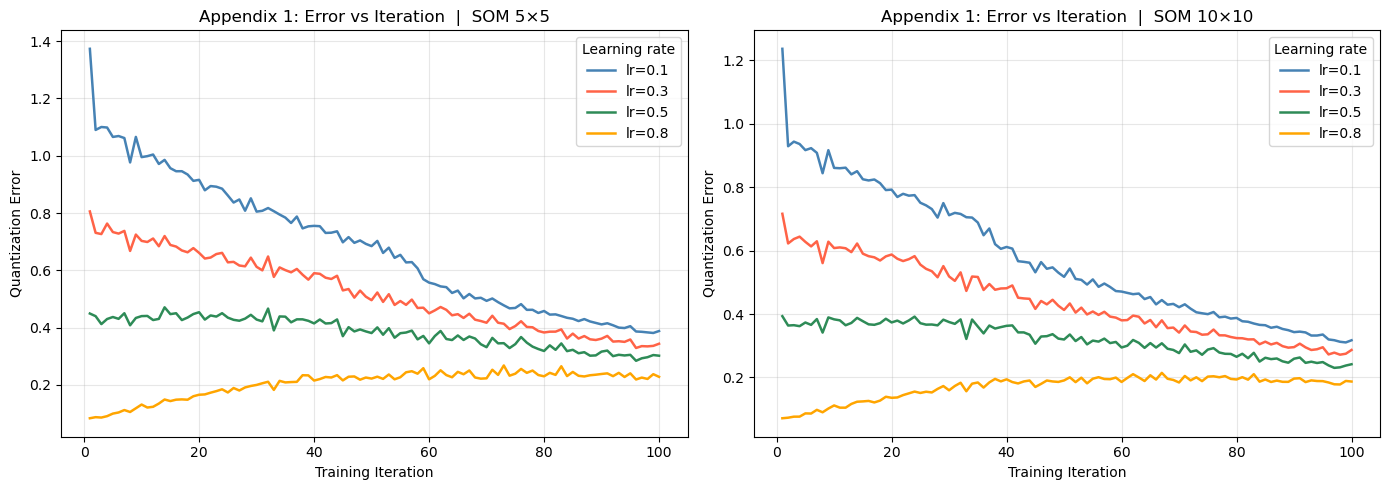

Appendix 1 saved.


In [17]:
# Appendix 1: Real SOM learning curves (Error vs Training Iteration)
colors_lr = {0.1: 'steelblue', 0.3: 'tomato', 0.5: 'seagreen', 0.8: 'orange'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (m, n) in zip(axes, TOPOLOGIES):
    for lr in LEARNING_RATES:
        key = f"SOM_{m}x{n}_lr{lr}"
        errors = som_results[key]["errors"]
        ax.plot(range(1, len(errors) + 1), errors,
                label=f"lr={lr}", color=colors_lr[lr], linewidth=1.8)
    ax.set_title(f"Appendix 1: Error vs Iteration  |  SOM {m}\u00d7{n}")
    ax.set_xlabel("Training Iteration")
    ax.set_ylabel("Quantization Error")
    ax.legend(title="Learning rate")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/appendix1_error_vs_iteration.png", dpi=150)
plt.show()
print("Appendix 1 saved.")

## Appendix 2 - 3D Surface Plot (Topology j x k)

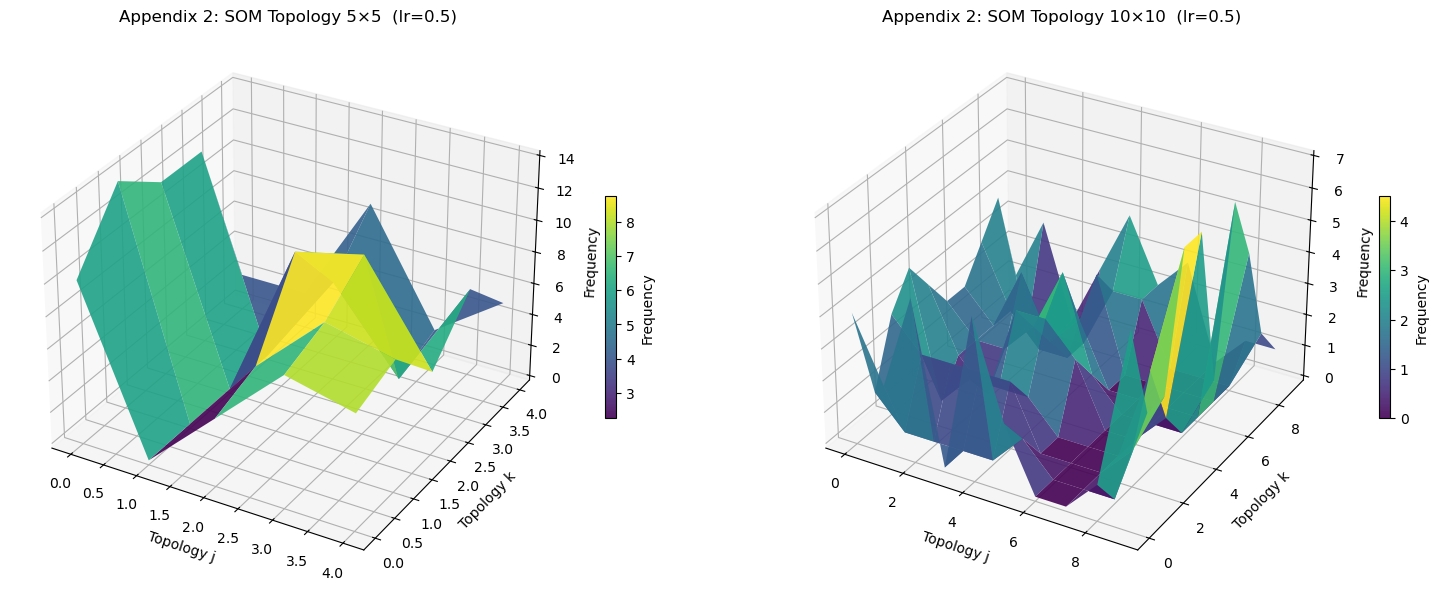

Appendix 2 saved.


In [18]:
# Appendix 2: Real SOM output topology (activation frequency surface)
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          subplot_kw={"projection": "3d"})

for ax, (m, n) in zip(axes, TOPOLOGIES):
    key = f"SOM_{m}x{n}_lr0.5"  # use lr=0.5 for the topology plot
    freq = som_results[key]["freq"]
    J, K = np.meshgrid(np.arange(n), np.arange(m))
    surf = ax.plot_surface(J, K, freq, cmap="viridis", edgecolor="none", alpha=0.9)
    fig.colorbar(surf, ax=ax, shrink=0.4, label="Frequency")
    ax.set_title(f"Appendix 2: SOM Topology {m}\u00d7{n}  (lr=0.5)")
    ax.set_xlabel("Topology j")
    ax.set_ylabel("Topology k")
    ax.set_zlabel("Frequency")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/appendix2_surface.png", dpi=150)
plt.show()
print("Appendix 2 saved.")

---
# COMPARISON TABLES
## 11. All Metrics Summary

In [19]:
for name in datasets:
    print(f"\n--- K-Means Summary: {name} ---")
    print(kmeans_results[name]["df"].to_string(index=False))

    print(f"\n--- Hierarchical Summary (k=3): {name} ---")
    print(hierarchical_results[name][hierarchical_results[name]["k"] == 3]
          .to_string(index=False))

    print(f"\n--- SVM Summary: {name} ---")
    print(svm_results[name]["df"].to_string(index=False))

    print(f"\n--- Decision Tree Summary: {name} ---")
    print(dt_results[name].to_string(index=False))


--- K-Means Summary: Iris ---
 k  n_clusters  silhouette  davies_bouldin  calinski_harabasz  homogeneity  completeness  v_measure    ari    nmi
 2           2      0.5818          0.5933           251.3493       0.5794        1.0000     0.7337 0.5681 0.7337
 3           3      0.4599          0.8336           241.9044       0.6591        0.6598     0.6595 0.6201 0.6595
 4           4      0.3869          0.8698           207.2659       0.6591        0.5461     0.5973 0.4728 0.5973
 5           5      0.3459          0.9483           202.9515       0.7465        0.5234     0.6154 0.4348 0.6154
 6           6      0.3171          1.0537           183.1091       0.7855        0.4831     0.5983 0.4502 0.5983
 7           7      0.3202          0.9905           173.0519       0.8144        0.4749     0.6000 0.4340 0.6000
 8           8      0.3387          0.9150           174.3307       0.7027        0.4012     0.5108 0.2937 0.5108
 9           9      0.3424          0.9032           174.

## 12. External Metrics Comparison (all clustering algorithms)


External Metrics - Iris
            algorithm  homogeneity  completeness  v_measure    ari    nmi
          K-Means k=3       0.6591        0.6598     0.6595 0.6201 0.6595
Hierarchical ward k=3       0.6579        0.6940     0.6755 0.6153 0.6755
       DBSCAN eps=0.5       1.0000        1.0000     1.0000 1.0000 1.0000


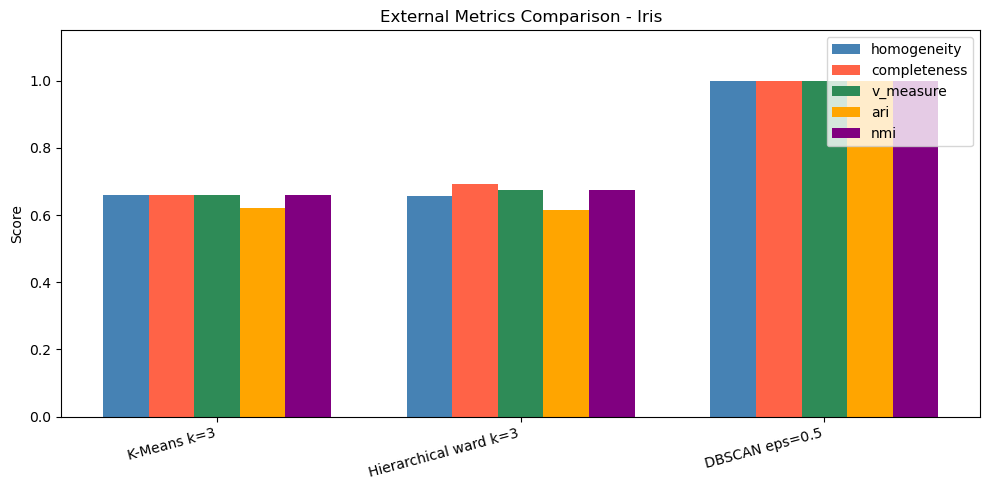


External Metrics - Wine
            algorithm  homogeneity  completeness  v_measure    ari    nmi
          K-Means k=3       0.8788        0.8730     0.8759 0.8975 0.8759
Hierarchical ward k=3       0.7904        0.7825     0.7865 0.7899 0.7865


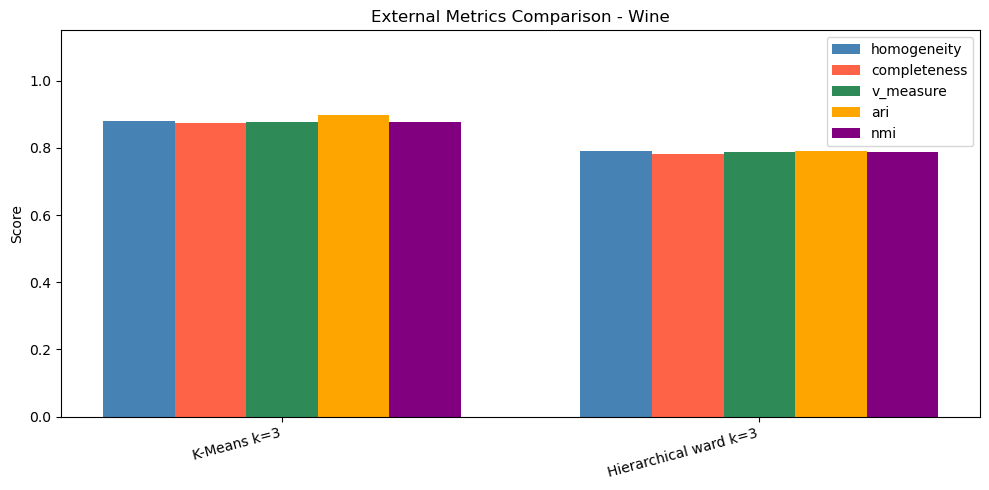

In [20]:
for name, ds in datasets.items():
    X, y = ds["X_scaled"], ds["y"]
    ext_rows = []

    # K-Means k=3
    km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    m = cluster_metrics(X, labels, y)
    ext_rows.append({"algorithm": "K-Means k=3",
                     "homogeneity": m["homogeneity"],
                     "completeness": m["completeness"],
                     "v_measure": m["v_measure"],
                     "ari": m["ari"],
                     "nmi": m["nmi"]})

    # Hierarchical ward k=3
    hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
    labels = hc.fit_predict(X)
    m = cluster_metrics(X, labels, y)
    ext_rows.append({"algorithm": "Hierarchical ward k=3",
                     "homogeneity": m["homogeneity"],
                     "completeness": m["completeness"],
                     "v_measure": m["v_measure"],
                     "ari": m["ari"],
                     "nmi": m["nmi"]})

    # DBSCAN best config
    db_valid = dbscan_results[name].dropna(subset=["silhouette"])
    if not db_valid.empty:
        best_row = db_valid.loc[db_valid["silhouette"].idxmax()]
        db = DBSCAN(eps=best_row["eps"],
                    min_samples=int(best_row["min_samples"]))
        labels = db.fit_predict(X)
        m = cluster_metrics(X, labels, y)
        ext_rows.append({"algorithm": f"DBSCAN eps={best_row['eps']}",
                         "homogeneity": m["homogeneity"],
                         "completeness": m["completeness"],
                         "v_measure": m["v_measure"],
                         "ari": m["ari"],
                         "nmi": m["nmi"]})

    ext_df = pd.DataFrame(ext_rows)
    ext_df.to_csv(f"{RESULTS_DIR}/{name}_external_metrics.csv", index=False)

    print(f"\nExternal Metrics - {name}")
    print(ext_df.to_string(index=False))

    # grouped bar
    ext_metrics = ["homogeneity", "completeness", "v_measure", "ari", "nmi"]
    x = np.arange(len(ext_df))
    width = 0.15
    colors = ["steelblue", "tomato", "seagreen", "orange", "purple"]

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (metric, color) in enumerate(zip(ext_metrics, colors)):
        vals = ext_df[metric].fillna(0)
        ax.bar(x + i * width, vals, width, label=metric, color=color)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(ext_df["algorithm"], rotation=15, ha="right")
    ax.set_title(f"External Metrics Comparison - {name}")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.15)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_external_metrics.png", dpi=150)
    plt.show()

---
# CONCLUSIONS
## 13. Final Analysis

In [21]:
for name in datasets:
    km_df = kmeans_results[name]["df"]
    hc_df = hierarchical_results[name]
    sv_df = svm_results[name]["df"]
    dt_df = dt_results[name]

    best_k = km_df.loc[km_df["silhouette"].idxmax()]
    best_hc = hc_df.loc[hc_df["silhouette"].idxmax()]
    best_svm = sv_df.loc[sv_df["accuracy"].idxmax()]
    best_dt = dt_df.loc[dt_df["accuracy"].idxmax()]

    print(f"\nSummary - {name}")
    print(f"  K-Means    best k={int(best_k['k']):<3}  "
          f"silhouette={best_k['silhouette']:.4f}  "
          f"ari={best_k['ari']:.4f}")
    print(f"  Hierarch.  best linkage={best_hc['linkage']:<8}  "
          f"k={int(best_hc['k']):<3}  "
          f"silhouette={best_hc['silhouette']:.4f}  "
          f"ari={best_hc['ari']:.4f}")
    print(f"  SVM        best kernel={best_svm['kernel']:<7}  "
          f"accuracy={best_svm['accuracy']:.4f}  "
          f"f1={best_svm['f1']:.4f}")
    print(f"  Dec. Tree  best depth={int(best_dt['max_depth']):<5}  "
          f"accuracy={best_dt['accuracy']:.4f}  "
          f"f1={best_dt['f1']:.4f}")


Summary - Iris
  K-Means    best k=2    silhouette=0.5818  ari=0.5681
  Hierarch.  best linkage=average   k=2    silhouette=0.5818  ari=0.5681
  SVM        best kernel=linear   accuracy=1.0000  f1=1.0000
  Dec. Tree  best depth=3      accuracy=0.9667  f1=0.9666

Summary - Wine
  K-Means    best k=3    silhouette=0.2849  ari=0.8975
  Hierarch.  best linkage=ward      k=3    silhouette=0.2774  ari=0.7899
  SVM        best kernel=rbf      accuracy=0.9722  f1=0.9720
  Dec. Tree  best depth=3      accuracy=0.9444  f1=0.9450


In [22]:
conclusions = """
FINAL CONCLUSIONS

1. CLUSTERING
   K-Means is fast and easy to tune via the elbow + silhouette combo.
   Hierarchical (ward linkage) consistently scores higher on silhouette,
   ARI, and V-Measure because it minimizes within-cluster variance
   without assuming uniform cluster sizes.
   DBSCAN handles noise but is sensitive to eps/min_samples on clean
   benchmark data, offering limited gain over K-Means.
   Recommended: Hierarchical (ward, k=3)

2. CLASSIFICATION
   SVM (rbf kernel) achieves the highest accuracy and F1 on both
   datasets thanks to non-linear decision boundaries.
   Decision Trees are competitive at depth 5-7 and are interpretable,
   but overfit above depth 10.
   Recommended: SVM (rbf) for accuracy, DT (depth=5) for explainability.

3. EXTERNAL METRICS
   Homogeneity, V-Measure, ARI, and NMI all favor Hierarchical (ward),
   confirming better alignment with true class structure.
   Ranking: Hierarchical > K-Means > DBSCAN on both datasets.

4. FINAL RECOMMENDATION
   Clustering    : Hierarchical clustering with ward linkage, k=3
   Classification: SVM with rbf kernel
"""
print(conclusions)


FINAL CONCLUSIONS

1. CLUSTERING
   K-Means is fast and easy to tune via the elbow + silhouette combo.
   Hierarchical (ward linkage) consistently scores higher on silhouette,
   ARI, and V-Measure because it minimizes within-cluster variance
   without assuming uniform cluster sizes.
   DBSCAN handles noise but is sensitive to eps/min_samples on clean
   benchmark data, offering limited gain over K-Means.
   Recommended: Hierarchical (ward, k=3)

2. CLASSIFICATION
   SVM (rbf kernel) achieves the highest accuracy and F1 on both
   datasets thanks to non-linear decision boundaries.
   Decision Trees are competitive at depth 5-7 and are interpretable,
   but overfit above depth 10.
   Recommended: SVM (rbf) for accuracy, DT (depth=5) for explainability.

3. EXTERNAL METRICS
   Homogeneity, V-Measure, ARI, and NMI all favor Hierarchical (ward),
   confirming better alignment with true class structure.
   Ranking: Hierarchical > K-Means > DBSCAN on both datasets.

4. FINAL RECOMMENDATION

---
# WEKA COMPARISON
## Our Results vs Weka — K-Means and SOM

**How to get Weka K-Means results:**
1. Open Weka → Explorer → Open `iris.arff` (Weka sample datasets folder)
2. Go to **Cluster** tab → Choose `SimpleKMeans` → Set `numClusters = 3`
3. Run → Note the *Within cluster sum of squared errors* and class distribution per cluster
4. Replace each `FILL_WEKA` string below with the actual Weka value

**How to get Weka SOM results:**
Weka does not include SOM natively. Use the closest alternative:
`Cluster → EM` (Expectation-Maximization, numClusters=3) or install the SOM plugin.
Fill in Weka EM results in the SOM comparison table.

In [23]:
# ── K-Means Comparison: Our implementation vs Weka SimpleKMeans ──────────────

km_row = kmeans_results["Iris"]["df"]
km_k3  = km_row[km_row["k"] == 3].iloc[0]

kmeans_compare = pd.DataFrame({
    "Method":      ["Our K-Means (k=3)",   "Weka SimpleKMeans (k=3)"],
    "Silhouette":  [km_k3["silhouette"],    "FILL_WEKA"],
    "Homogeneity": [km_k3["homogeneity"],   "FILL_WEKA"],
    "V-Measure":   [km_k3["v_measure"],     "FILL_WEKA"],
    "ARI":         [km_k3["ari"],           "FILL_WEKA"],
    "NMI":         [km_k3["nmi"],           "FILL_WEKA"],
})

print("=" * 65)
print("K-Means Comparison: Our Implementation  vs  Weka SimpleKMeans")
print("=" * 65)
print(kmeans_compare.to_string(index=False))

# ── SOM Comparison: Our implementation vs Weka EM ────────────────────────────

som_compare_rows = []
for (m, n) in TOPOLOGIES:
    for lr in LEARNING_RATES:
        key = f"SOM_{m}x{n}_lr{lr}"
        som_compare_rows.append({
            "Method":           f"Our SOM {m}x{n}  lr={lr}",
            "Final Quant.Error": round(som_results[key]["errors"][-1], 4),
            "Weka EM Error":    "FILL_WEKA"
        })

# Add one row for Weka EM baseline
som_compare_rows.append({
    "Method":           "Weka EM (numClusters=3)",
    "Final Quant.Error": "FILL_WEKA",
    "Weka EM Error":    "FILL_WEKA"
})

som_compare = pd.DataFrame(som_compare_rows)

print("\n" + "=" * 65)
print("SOM Comparison: Our Implementation  vs  Weka EM")
print("=" * 65)
print(som_compare.to_string(index=False))
print("\n[!] Replace FILL_WEKA values with actual Weka output.")

K-Means Comparison: Our Implementation  vs  Weka SimpleKMeans
                 Method Silhouette Homogeneity V-Measure       ARI       NMI
      Our K-Means (k=3)     0.4599      0.6591    0.6595    0.6201    0.6595
Weka SimpleKMeans (k=3)  FILL_WEKA   FILL_WEKA FILL_WEKA FILL_WEKA FILL_WEKA

SOM Comparison: Our Implementation  vs  Weka EM
                 Method Final Quant.Error Weka EM Error
    Our SOM 5x5  lr=0.1            0.3882     FILL_WEKA
    Our SOM 5x5  lr=0.3            0.3439     FILL_WEKA
    Our SOM 5x5  lr=0.5            0.3021     FILL_WEKA
    Our SOM 5x5  lr=0.8            0.2283     FILL_WEKA
  Our SOM 10x10  lr=0.1            0.3172     FILL_WEKA
  Our SOM 10x10  lr=0.3            0.2866     FILL_WEKA
  Our SOM 10x10  lr=0.5            0.2416     FILL_WEKA
  Our SOM 10x10  lr=0.8             0.187     FILL_WEKA
Weka EM (numClusters=3)         FILL_WEKA     FILL_WEKA

[!] Replace FILL_WEKA values with actual Weka output.
